In [15]:
import pickle
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score

Dataset = "HUST"
output_dir = Path("..", "engineered_data")
filename = output_dir / f"processed_battery_features_{Dataset}.pkl"

print(filename)
with open(filename, "rb") as f:
    feature_df = pickle.load(f)

# feature_df = pd.read_pickle(filename)

..\engineered_data\processed_battery_features_HUST.pkl


In [16]:
# Feature selection

model_df = feature_df.dropna().copy()

feature_columns = [
    "I_mean",
    "I_std",
    "charge_duration",
    "discharge_duration",
    "V_mean",
    "V_std"
]

target_column = "SOH"

features = model_df[feature_columns]
target = model_df[target_column]

In [17]:
# Split the data into training and testing sets

features_train, features_test, target_train, target_test = train_test_split(
    features,
    target,
    test_size=0.2,
    random_state=42
)

In [18]:
# Standardize the features
scaler = StandardScaler()

features_train = pd.DataFrame(
    scaler.fit_transform(features_train),
    columns=features.columns,
    index=features_train.index
)

features_test = pd.DataFrame(
    scaler.transform(features_test),
    columns=features.columns,
    index=features_test.index
)

In [19]:
# Train a linear regression model

model = LinearRegression()

model.fit(features_train, target_train)

target_pred = model.predict(features_test)

In [20]:
# Evaluate the model

mae = mean_absolute_error(target_test, target_pred)
r2 = r2_score(target_test, target_pred)

print(f"MAE: {mae:.4f}")
print(f"R² : {r2:.4f}")

MAE: 0.0174
R² : 0.9046


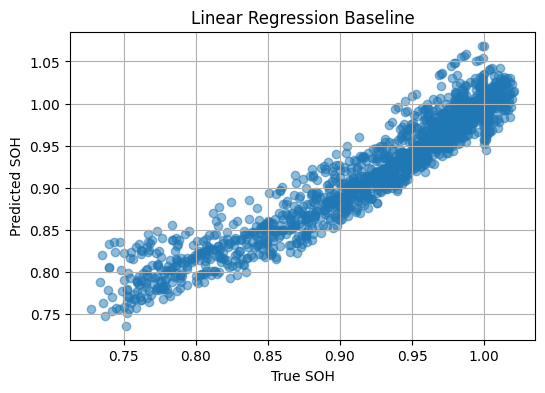

<Figure size 640x480 with 0 Axes>

In [22]:
# Visualize the results

plt.figure(figsize=(6, 4))

plt.scatter(target_test, target_pred, alpha=0.5)

plt.xlabel("True SOH")
plt.ylabel("Predicted SOH")
plt.title("Linear Regression Baseline")

plt.grid(True)

plt.show()

# Zielordner anlegen
figure_dir = Path("..", "figures")
figure_dir.mkdir(exist_ok=True)

plt.savefig(
    figure_dir / f"linear_regression_baseline_{Dataset}.png",
    dpi=300,
    bbox_inches="tight"
)